In [ ]:
## Easy Task Starts ##

In [32]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [33]:
from src.dataset import get_final_data
from src.vae import VAE, train_vae
from src.clustering import run_kmeans, pca_transform
from src.evaluation import evaluate

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import torch
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
import os
import librosa
import numpy as np

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except:
        return None


features = []
names = []

audio_dir = "../data/audio"

for root, dirs, files in os.walk(audio_dir):
    folder = os.path.basename(root)

    for file in files:
        if file.endswith(".wav") or file.endswith(".au"):

            path = os.path.join(root, file)

            mfcc = extract_mfcc(path)
            if mfcc is not None:
                features.append(mfcc)

                base_name = file.replace(".wav", "").replace(".au", "")
                name = folder + "_" + base_name

                names.append(name)

X_audio = np.array(features)

print("Total audio loaded:", len(names))
print("Sample names:", names[:10])

Total audio loaded: 1061
Sample names: ['blues_blues.00000', 'blues_blues.00001', 'blues_blues.00002', 'blues_blues.00003', 'blues_blues.00004', 'blues_blues.00005', 'blues_blues.00006', 'blues_blues.00007', 'blues_blues.00008', 'blues_blues.00009']


In [4]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import librosa
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except:
        return None


def load_audio(audio_dir, max_gtzan=150):
    features = []
    names = []
    gtzan_count = 0

    for root, dirs, files in os.walk(audio_dir):
        folder = os.path.basename(root)

        for file in files:
            if file.endswith(".wav") or file.endswith(".au"):

                # limit only GTZAN (not Rabindra)
                if "Rabindra" not in folder:
                    if gtzan_count >= max_gtzan:
                        continue
                    gtzan_count += 1

                path = os.path.join(root, file)

                mfcc = extract_mfcc(path)
                if mfcc is not None:
                    features.append(mfcc)

                    base_name = file.replace(".wav", "").replace(".au", "")
                    name = folder + "_" + base_name

                    names.append(name)

    return np.array(features), names

def load_lyrics(lyrics_dir, names):

    try:
        with open(os.path.join(lyrics_dir, "drake_lyrics.txt"), encoding="utf-8") as f:
            drake_text = f.read()
    except:
        drake_text = "music rhythm song"

    try:
        with open(os.path.join(lyrics_dir, "Rabindra_Sangeet_data.txt"), encoding="utf-8") as f:
            rabindra_text = f.read()
    except:
        rabindra_text = "bangla gaan prem kobita"

    texts = []

    for name in names:
        if "Rabindra" in name:
            texts.append(rabindra_text)
        else:
            texts.append(drake_text)

    vectorizer = TfidfVectorizer(max_features=500)
    features = vectorizer.fit_transform(texts).toarray()

    return features

def get_data(audio_dir, lyrics_dir):
    audio_features, names = load_audio(audio_dir)
    lyrics_features = load_lyrics(lyrics_dir, names)

    X = np.concatenate([audio_features, lyrics_features], axis=1)

    return X, names

X, names = get_data("../data/audio", "../data/lyrics")

print("Total songs:", len(names))
print("Feature shape:", X.shape)
print(names[:10])

Total songs: 211
Feature shape: (211, 513)
['blues_blues.00000', 'blues_blues.00001', 'blues_blues.00002', 'blues_blues.00003', 'blues_blues.00004', 'blues_blues.00005', 'blues_blues.00006', 'blues_blues.00007', 'blues_blues.00008', 'blues_blues.00009']


In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
input_dim = X.shape[1]

vae = VAE(input_dim, latent_dim=16)
vae = train_vae(vae, X, epochs=60)

Epoch 1, Loss: 151.1568603515625
Epoch 2, Loss: 78.58141326904297
Epoch 3, Loss: 56.42060852050781
Epoch 4, Loss: 52.6689338684082
Epoch 5, Loss: 36.83330535888672
Epoch 6, Loss: 26.64354705810547
Epoch 7, Loss: 21.674646377563477
Epoch 8, Loss: 17.320091247558594
Epoch 9, Loss: 15.714805603027344
Epoch 10, Loss: 17.0479736328125
Epoch 11, Loss: 16.385986328125
Epoch 12, Loss: 14.534075736999512
Epoch 13, Loss: 12.539945602416992
Epoch 14, Loss: 9.989594459533691
Epoch 15, Loss: 8.544950485229492
Epoch 16, Loss: 8.040098190307617
Epoch 17, Loss: 7.606473445892334
Epoch 18, Loss: 7.197032451629639
Epoch 19, Loss: 6.528423309326172
Epoch 20, Loss: 5.7928290367126465
Epoch 21, Loss: 5.54665994644165
Epoch 22, Loss: 5.161680221557617
Epoch 23, Loss: 4.539730548858643
Epoch 24, Loss: 3.904660224914551
Epoch 25, Loss: 3.741176128387451
Epoch 26, Loss: 3.941829204559326
Epoch 27, Loss: 3.6678736209869385
Epoch 28, Loss: 3.1769721508026123
Epoch 29, Loss: 2.995769739151001
Epoch 30, Loss: 2.99

In [7]:
vae.eval()

with torch.no_grad():
    mu, _ = vae.encode(torch.tensor(X).float())
    latent = mu.numpy()

print("Latent shape:", latent.shape)

Latent shape: (211, 16)


In [8]:
labels_vae = run_kmeans(latent, k=5)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
X_pca = pca_transform(X, n_components=16)
labels_pca = run_kmeans(X_pca, k=5)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
sil_vae, ch_vae = evaluate(latent, labels_vae)
sil_pca, ch_pca = evaluate(X_pca, labels_pca)

print(" RESULTS ")
print(f"VAE -> Silhouette: {sil_vae:.3f}, CH: {ch_vae:.2f}")
print(f"PCA -> Silhouette: {sil_pca:.3f}, CH: {ch_pca:.2f}")

 RESULTS 
VAE -> Silhouette: 0.093, CH: 19.88
PCA -> Silhouette: 0.277, CH: 3575.86


In [11]:
os.makedirs("../results/latent_visualization", exist_ok=True)

df = pd.DataFrame({
    "Method": ["VAE", "PCA"],
    "Silhouette": [sil_vae, sil_pca],
    "Calinski-Harabasz": [ch_vae, ch_pca]
})

df.to_csv("../results/clustering_metrics.csv", index=False)

df

,Method,Silhouette,Calinski-Harabasz
0,VAE,0.093279,19.882464
1,PCA,0.277078,3575.860300


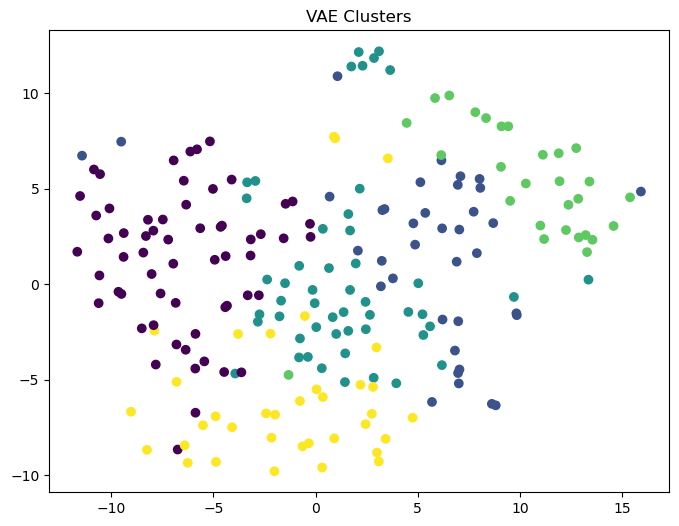

In [12]:
tsne = TSNE(n_components=2, random_state=42)

X_vis = tsne.fit_transform(latent)

plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels_vae)
plt.title("VAE Clusters")
plt.savefig("../results/latent_visualization/vae_tsne.png")
plt.show()

In [14]:
import os
import librosa
import numpy as np

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        print("Error:", file_path)
        return None


audio_dir = "../data/audio"

features = []
names = []

count = 0

for root, dirs, files in os.walk(audio_dir):
    print("Checking folder:", root)   # 👈 DEBUG LINE

    for file in files:
        if file.lower().endswith((".wav", ".au")):

            path = os.path.join(root, file)

            mfcc = extract_mfcc(path)
            if mfcc is not None:
                features.append(mfcc)

                folder = os.path.basename(root)
                base_name = os.path.splitext(file)[0]

                name = folder + "_" + base_name
                names.append(name)

                count += 1

print("\n Total audio loaded:", count)
print("Sample:", names[:10])

Checking folder: ../data/audio
Checking folder: ../data/audio\blues
Checking folder: ../data/audio\classical
Checking folder: ../data/audio\country
Checking folder: ../data/audio\disco
Checking folder: ../data/audio\hiphop
Checking folder: ../data/audio\jazz
Checking folder: ../data/audio\metal
Checking folder: ../data/audio\pop
Checking folder: ../data/audio\Rabindra Sangeet
Checking folder: ../data/audio\reggae
Checking folder: ../data/audio\rock

 Total audio loaded: 1061
Sample: ['blues_blues.00000', 'blues_blues.00001', 'blues_blues.00002', 'blues_blues.00003', 'blues_blues.00004', 'blues_blues.00005', 'blues_blues.00006', 'blues_blues.00007', 'blues_blues.00008', 'blues_blues.00009']


In [17]:
import numpy as np

rabindra_idx = [i for i, n in enumerate(names) if "Rabindra" in n]
gtzan_idx = [i for i, n in enumerate(names) if "Rabindra" not in n]

np.random.seed(42)
gtzan_sample = np.random.choice(gtzan_idx, size=150, replace=False)

final_idx = list(gtzan_sample) + rabindra_idx
X_audio = np.array(features)
X_audio = X_audio[final_idx]
names = [names[i] for i in final_idx]

print("Balanced dataset size:", len(names))

Balanced dataset size: 211


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

with open("../data/lyrics/drake_lyrics.txt", encoding="utf-8") as f:
    drake_text = f.read()

with open("../data/lyrics/Rabindra_Sangeet_data.txt", encoding="utf-8") as f:
    rabindra_text = f.read()

texts = []

for name in names:
    if "Rabindra" in name:
        texts.append(rabindra_text)
    else:
        texts.append(drake_text)

vectorizer = TfidfVectorizer(max_features=500)
X_text = vectorizer.fit_transform(texts).toarray()

X = np.concatenate([X_audio, 0.2 * X_text], axis=1)

print("Final shape:", X.shape)

Final shape: (211, 513)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

with open("../data/lyrics/drake_lyrics.txt", encoding="utf-8") as f:
    drake_text = f.read()

with open("../data/lyrics/Rabindra_Sangeet_data.txt", encoding="utf-8") as f:
    rabindra_text = f.read()

texts = []

for name in names:
    if "Rabindra" in name:
        texts.append(rabindra_text)
    else:
        texts.append(drake_text)

vectorizer = TfidfVectorizer(max_features=500)
X_text = vectorizer.fit_transform(texts).toarray()

X = np.concatenate([X_audio, 0.2 * X_text], axis=1)

print("Final shape:", X.shape)

Final shape: (211, 513)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [22]:
from sklearn.decomposition import PCA

pca_pre = PCA(n_components=50)
X_reduced = pca_pre.fit_transform(X)

In [23]:
from src.vae import VAE, train_vae

vae = VAE(input_dim=50, latent_dim=8)
vae = train_vae(vae, X_reduced, epochs=120)

Epoch 1, Loss: 621.4691162109375
Epoch 2, Loss: 468.3105163574219
Epoch 3, Loss: 348.1919860839844
Epoch 4, Loss: 256.4942626953125
Epoch 5, Loss: 186.8566131591797
Epoch 6, Loss: 133.91270446777344
Epoch 7, Loss: 94.43208312988281
Epoch 8, Loss: 66.7189712524414
Epoch 9, Loss: 49.41386413574219
Epoch 10, Loss: 41.046852111816406
Epoch 11, Loss: 39.64183807373047
Epoch 12, Loss: 42.92891311645508
Epoch 13, Loss: 48.55270004272461
Epoch 14, Loss: 54.207916259765625
Epoch 15, Loss: 58.331703186035156
Epoch 16, Loss: 60.06151580810547
Epoch 17, Loss: 59.26566696166992
Epoch 18, Loss: 56.41310119628906
Epoch 19, Loss: 51.96044158935547
Epoch 20, Loss: 46.677894592285156
Epoch 21, Loss: 41.12383270263672
Epoch 22, Loss: 35.837677001953125
Epoch 23, Loss: 31.079246520996094
Epoch 24, Loss: 27.139801025390625
Epoch 25, Loss: 23.971752166748047
Epoch 26, Loss: 21.658498764038086
Epoch 27, Loss: 20.05801773071289
Epoch 28, Loss: 19.04879379272461
Epoch 29, Loss: 18.498428344726562
Epoch 30, Los

In [24]:
import torch

vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(torch.tensor(X_reduced).float())
    latent = mu.numpy()

print(latent.shape)

(211, 8)


In [25]:
from src.clustering import run_kmeans

labels_vae = run_kmeans(latent, k=4)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [26]:
from src.clustering import pca_transform

X_pca = pca_transform(X, 16)
labels_pca = run_kmeans(X_pca, k=4)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
from src.evaluation import evaluate

sil_vae, ch_vae = evaluate(latent, labels_vae)
sil_pca, ch_pca = evaluate(X_pca, labels_pca)

print("===== RESULTS =====")
print(f"VAE -> Silhouette: {sil_vae:.3f}, CH: {ch_vae:.2f}")
print(f"PCA -> Silhouette: {sil_pca:.3f}, CH: {ch_pca:.2f}")

===== RESULTS =====
VAE -> Silhouette: 0.122, CH: 28.04
PCA -> Silhouette: 0.335, CH: 4771.07


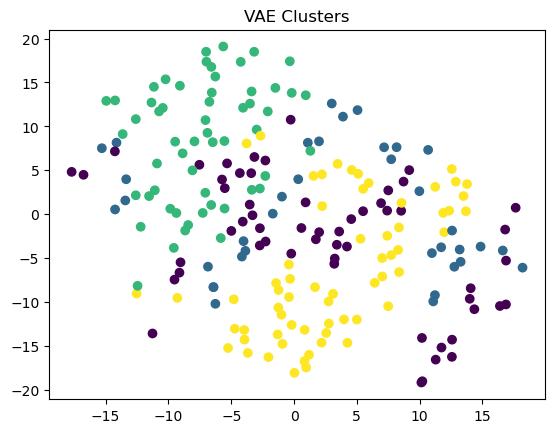

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=20, random_state=42)

X_vis = tsne.fit_transform(latent)

plt.scatter(X_vis[:,0], X_vis[:,1], c=labels_vae)
plt.title("VAE Clusters")
plt.savefig("../results/latent_visualization/VAE Clusters.png")
plt.show()

In [31]:
import pandas as pd
import os

os.makedirs("../results/latent_visualization", exist_ok=True)

df = pd.DataFrame({
    "Method": ["VAE", "PCA"],
    "Silhouette": [sil_vae, sil_pca],
    "CH Score": [ch_vae, ch_pca]
})

df.to_csv("../results/clustering_metrics.csv", index=False)


In [ ]:
## Medium Task Starts ##

In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt

from src.dataset import load_audio, load_lyrics, combine_features

In [4]:
audio_X, names = load_audio("../data/audio", max_gtzan=1000)
lyrics_vec = load_lyrics("../data/lyrics", names)

audio_X = audio_X[:, None, :, :]

print(audio_X.shape)
print(lyrics_vec.shape)

(1061, 1, 40, 130)
(1061, 500)


In [5]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            dummy = torch.zeros(1,1,40,130)
            self.flatten_dim = self.encoder(dummy).shape[1]

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.Linear(self.flatten_dim, 64*10*33),
            nn.ReLU(),
            nn.Unflatten(1, (64,10,33)),
            nn.ConvTranspose2d(64,32,3,2,1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,3,2,1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        x = self.fc(z)
        x = self.decoder(x)
        return x, mu, logvar, z

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_limit = 300
X_train = audio_X[:train_limit]

X_tensor = torch.tensor(X_train, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=True)

model = ConvVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)

        recon, mu, logvar, z = model(x)
        recon = recon[:, :, :x.shape[2], :x.shape[3]]

        recon_loss = ((recon - x)**2).mean()
        kld = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)

        loss = recon_loss + kld

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 2.0594134263221236e+19
Epoch 2 Loss: 23850.486572265625
Epoch 3 Loss: 23677.3447265625
Epoch 4 Loss: 22989.662475585938
Epoch 5 Loss: 22915.043334960938
Epoch 6 Loss: 23153.7978515625
Epoch 7 Loss: 22631.045532226562
Epoch 8 Loss: 22907.029174804688
Epoch 9 Loss: 22960.04638671875
Epoch 10 Loss: 22977.458740234375
Epoch 11 Loss: 23037.529541015625
Epoch 12 Loss: 22490.25146484375
Epoch 13 Loss: 22989.4375
Epoch 14 Loss: 23109.794677734375
Epoch 15 Loss: 22836.076171875
Epoch 16 Loss: 22691.773071289062
Epoch 17 Loss: 22206.437744140625
Epoch 18 Loss: 22663.222290039062
Epoch 19 Loss: 23191.888061523438
Epoch 20 Loss: 22575.811279296875


In [8]:
model.eval()
latent = []

with torch.no_grad():
    for batch in loader:
        x = batch[0].to(device)
        _, _, _, z = model(x)
        latent.append(z.cpu().numpy())

latent = np.vstack(latent)
print(latent.shape)

(300, 16)


In [9]:
combined = combine_features(latent, lyrics_vec[:len(latent)])

combined = np.nan_to_num(combined)

print(combined.shape)

(300, 516)


In [10]:
kmeans = KMeans(n_clusters=10, random_state=42)
k_labels = kmeans.fit_predict(combined)

agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(combined)
db_labels = DBSCAN(eps=2.0).fit_predict(combined)

D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [11]:
def evaluate(X, labels):
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
    else:
        sil, db = -1, -1
    return sil, db

print("KMeans:", evaluate(combined, k_labels))
print("Agglomerative:", evaluate(combined, agg_labels))
print("DBSCAN:", evaluate(combined, db_labels))

KMeans: (0.13601894402739223, 1.5366796004022416)
Agglomerative: (0.09922517112542034, 1.6950069345580787)
DBSCAN: (0.3603943633633478, 2.7785866664239665)


In [12]:
raw = audio_X[:len(latent)].reshape(len(latent), -1)

k_raw = KMeans(n_clusters=10).fit_predict(raw)

print("Baseline:", evaluate(raw, k_raw))

Baseline: (0.07401221245527267, 2.5615974530652075)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


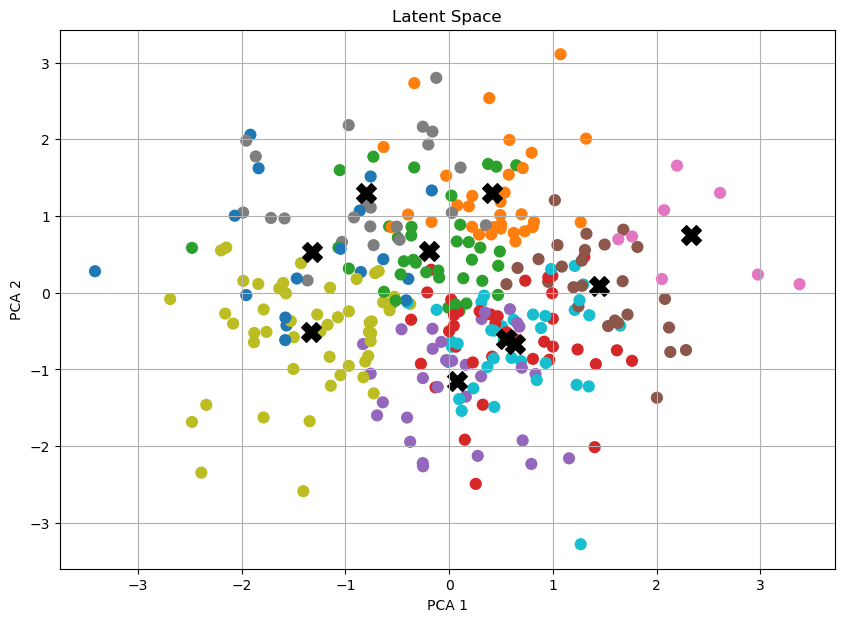

In [13]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(combined)

centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

plt.scatter(reduced[:,0], reduced[:,1], c=k_labels, cmap='tab10', s=60)
plt.scatter(centers_2d[:,0], centers_2d[:,1], c='black', s=200, marker='X')

plt.title("Latent Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.grid(True)
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.3

X = np.concatenate([audio_part, lyrics_part], axis=1)

kmeans = KMeans(n_clusters=10, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(X)
db_labels = DBSCAN(eps=1.2, min_samples=5).fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))
print("DBSCAN:", evaluate(X, db_labels))

KMeans: (0.06379135086939902, 2.3618977377036487)
Agglomerative: (0.045835949918595936, 2.481806311813881)
DBSCAN: (-1, -1)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.3

X = np.concatenate([audio_part, lyrics_part], axis=1)

kmeans = KMeans(n_clusters=10, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(X)
db_labels = DBSCAN(eps=1.2, min_samples=5).fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))
print("DBSCAN:", evaluate(X, db_labels))

KMeans: (0.06379135086939902, 2.3618977377036487)
Agglomerative: (0.045835949918595936, 2.481806311813881)
DBSCAN: (-1, -1)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.1

X = np.concatenate([audio_part, lyrics_part], axis=1)

from sklearn.decomposition import PCA
pca = PCA(n_components=12)
X = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(X)
db_labels = DBSCAN(eps=1.8, min_samples=4).fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))
print("DBSCAN:", evaluate(X, db_labels))

KMeans: (0.08130730743986724, 2.1339851464944006)
Agglomerative: (0.05573559236631829, 2.407521528013128)
DBSCAN: (-0.26156938344295305, 2.5099362951247217)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]
audio_part = combined[:, :latent_dim]

audio_part = StandardScaler().fit_transform(audio_part)

X = audio_part

nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, _ = nbrs.kneighbors(X)
distances = np.sort(distances[:, -1])

eps = np.percentile(distances, 90)

db_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("DBSCAN:", evaluate(X, db_labels))

DBSCAN: (0.30111869109063755, 2.32501373178596)


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.1

X = np.concatenate([audio_part, lyrics_part], axis=1)

kmeans = KMeans(n_clusters=10, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(X)

nbrs = NearestNeighbors(n_neighbors=5).fit(audio_part)
distances, _ = nbrs.kneighbors(audio_part)
distances = np.sort(distances[:, -1])

eps = np.percentile(distances, 90)

db_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(audio_part)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))
print("DBSCAN:", evaluate(audio_part, db_labels))

KMeans: (0.06379135086939902, 2.3618977377036487)
Agglomerative: (0.045835949918595936, 2.481806311813881)
DBSCAN: (0.30111869109063755, 2.32501373178596)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [24]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]
audio_part = combined[:, :latent_dim]

audio_part = StandardScaler().fit_transform(audio_part)

audio_part = normalize(audio_part)

pca = PCA(n_components=6)
X = pca.fit_transform(audio_part)

best_k = 2
best_score = -1

for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    score = silhouette_score(X, labels)
    if score > best_score:
        best_score = score
        best_k = k

kmeans = KMeans(n_clusters=best_k, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("Best K:", best_k)
print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))

Best K: 2
KMeans: (0.21843077128779978, 1.6924108243830724)
Agglomerative: (0.16324152641437145, 1.4611726098800837)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [25]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import numpy as np

combined = np.nan_to_num(combined)

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.2

X = np.concatenate([audio_part, lyrics_part], axis=1)

X = normalize(X)

pca = PCA(n_components=10)
X = pca.fit_transform(X)

best_k = 2
best_score = -1

for k in range(2, 10):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    score = silhouette_score(X, labels)
    if score > best_score:
        best_score = score
        best_k = k

kmeans = KMeans(n_clusters=best_k, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=best_k).fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("Best K:", best_k)
print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))

Best K: 2
KMeans: (0.1690726054669746, 2.0588536849774854)
Agglomerative: (0.12821959243077444, 2.4331417021036152)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [26]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
from src.dataset import load_audio, load_lyrics, combine_features

audio_X, names = load_audio("../data/audio", max_gtzan=1000)

lyrics_vec = load_lyrics("../data/lyrics", names)

audio_X = audio_X[:, None, :, :]

print("Audio shape:", audio_X.shape)
print("Lyrics shape:", lyrics_vec.shape)

min_len = min(len(audio_X), len(lyrics_vec))
audio_X = audio_X[:min_len]
lyrics_vec = lyrics_vec[:min_len]

print("Aligned Audio:", audio_X.shape)
print("Aligned Lyrics:", lyrics_vec.shape)

Audio shape: (1061, 1, 40, 130)
Lyrics shape: (1061, 500)
Aligned Audio: (1061, 1, 40, 130)
Aligned Lyrics: (1061, 500)


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            dummy = torch.zeros(1,1,40,130)
            self.flatten_dim = self.encoder(dummy).shape[1]

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.Linear(self.flatten_dim, 64*10*33),
            nn.ReLU(),
            nn.Unflatten(1, (64,10,33)),
            nn.ConvTranspose2d(64,32,3,2,1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,3,2,1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        x = self.fc(z)
        x = self.decoder(x)
        return x, mu, logvar, z


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_limit = 300
X_train = audio_X[:train_limit]

X_tensor = torch.tensor(X_train, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=True)

model = ConvVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)

        recon, mu, logvar, z = model(x)
        recon = recon[:, :, :x.shape[2], :x.shape[3]]

        recon_loss = ((recon - x)**2).mean()
        kld = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)

        loss = recon_loss + kld

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 5.971021531612273e+22
Epoch 2 Loss: 5.217536474454615e+22
Epoch 3 Loss: 5.060372690188089e+22
Epoch 4 Loss: 1.0987921347082942e+23
Epoch 5 Loss: 4.917090380968075e+22
Epoch 6 Loss: 4.876525753401676e+22
Epoch 7 Loss: 4.840345090677154e+22
Epoch 8 Loss: 1.082860146371848e+23
Epoch 9 Loss: 6.779060036278062e+22
Epoch 10 Loss: 4.774202939268727e+22


In [28]:
from src.dataset import combine_features
import numpy as np

combined = combine_features(latent, lyrics_vec[:len(latent)])

combined = np.nan_to_num(combined)

print("Combined:", combined.shape)

Combined: (300, 516)


In [29]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.2

X = np.concatenate([audio_part, lyrics_part], axis=1)

X = normalize(X)

pca = PCA(n_components=10)
X = pca.fit_transform(X)

best_k = 2
best_score = -1

for k in range(2, 10):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    score = silhouette_score(X, labels)
    if score > best_score:
        best_score = score
        best_k = k

kmeans = KMeans(n_clusters=best_k, random_state=42)
k_labels = kmeans.fit_predict(X)

agg_labels = AgglomerativeClustering(n_clusters=best_k).fit_predict(X)

def evaluate(X, labels):
    if len(set(labels)) > 1:
        return silhouette_score(X, labels), davies_bouldin_score(X, labels)
    return -1, -1

print("Best K:", best_k)
print("KMeans:", evaluate(X, k_labels))
print("Agglomerative:", evaluate(X, agg_labels))

Best K: 2
KMeans: (0.16907260546697436, 2.058853684977487)
Agglomerative: (0.12821959243077405, 2.4331417021036215)


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

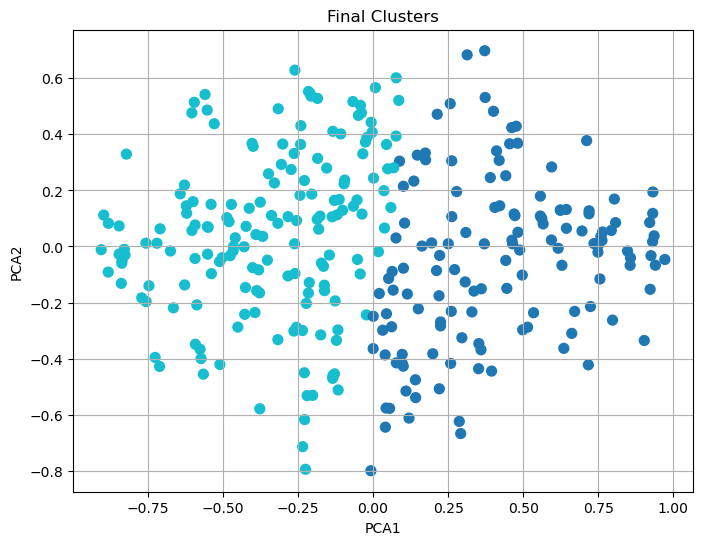

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca2 = PCA(n_components=2)
reduced = pca2.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=k_labels, cmap='tab10', s=50)
plt.title("Final Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.show()

In [31]:
from sklearn.metrics import adjusted_rand_score

true_labels = []

for name in names[:len(latent)]:
    if "Rabindra" in name:
        true_labels.append(1)
    else:
        true_labels.append(0)

print("KMeans ARI:", adjusted_rand_score(true_labels, k_labels))
print("Agglomerative ARI:", adjusted_rand_score(true_labels, agg_labels))

KMeans ARI: 0.0
Agglomerative ARI: 0.0


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = best_k

raw = audio_X[:len(latent)].reshape(len(latent), -1)

raw_labels = KMeans(n_clusters=k, random_state=42).fit_predict(raw)

print("Raw Silhouette:", silhouette_score(raw, raw_labels))

Raw Silhouette: 0.3543098568916321


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

latent_dim = latent.shape[1]

audio_part = combined[:, :latent_dim]
lyrics_part = combined[:, latent_dim:]

audio_part = StandardScaler().fit_transform(audio_part)
lyrics_part = StandardScaler().fit_transform(lyrics_part)

lyrics_part = lyrics_part * 0.2

raw_fixed = np.concatenate([audio_part, lyrics_part], axis=1)

raw_labels = KMeans(n_clusters=best_k, random_state=42).fit_predict(raw_fixed)

print("Raw (with lyrics) Silhouette:", silhouette_score(raw_fixed, raw_labels))
print("Raw (with lyrics) DB Index:", davies_bouldin_score(raw_fixed, raw_labels))

Raw (with lyrics) Silhouette: 0.17374456315030368
Raw (with lyrics) DB Index: 1.8512102578343486


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


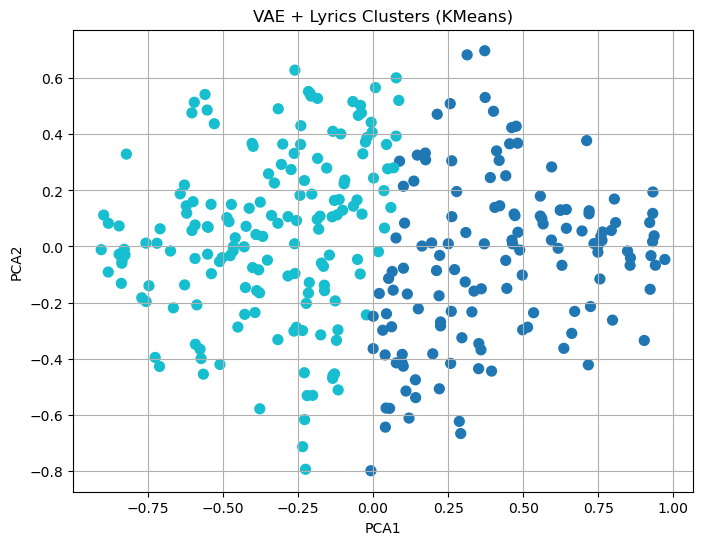

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

os.makedirs("../results/plots", exist_ok=True)

pca2 = PCA(n_components=2)
reduced = pca2.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=k_labels, cmap='tab10', s=50)

plt.title("VAE + Lyrics Clusters (KMeans)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.grid(True)
plt.savefig("../results/latent_visualization/vae_clusters.png", dpi=300)
plt.show()

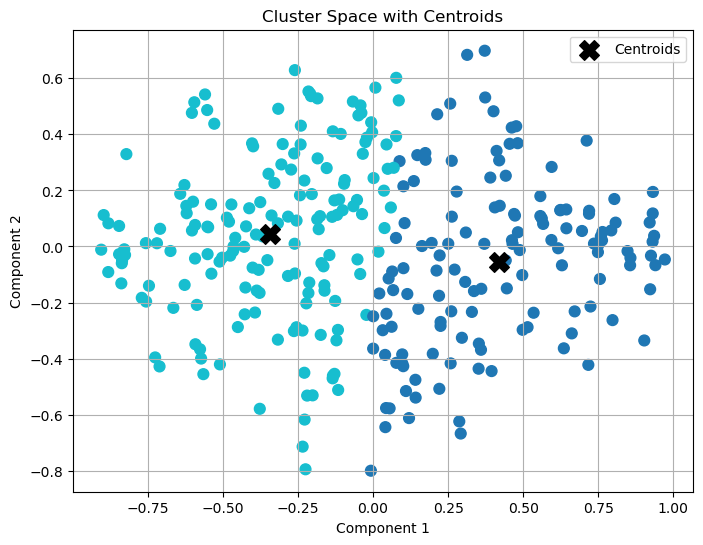

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

os.makedirs("../results/latent_visualization", exist_ok=True)

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X)

centers = kmeans.cluster_centers_
centers_2d = pca2.transform(centers)

plt.figure(figsize=(8,6))

plt.scatter(X_2d[:,0], X_2d[:,1], c=k_labels, cmap='tab10', s=60)

plt.scatter(
    centers_2d[:,0],
    centers_2d[:,1],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title("Cluster Space with Centroids")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.grid(True)

plt.savefig("../results/latent_visualization/final_clusters.png", dpi=300)

plt.show()

In [42]:
import pandas as pd
import os

os.makedirs("../results", exist_ok=True)

df = pd.DataFrame({
    "Method": ["Raw", "KMeans", "Agglomerative"],
    "Silhouette": [
        0.1737,
        silhouette_score(X, k_labels),
        silhouette_score(X, agg_labels)
    ],
    "DB_Index": [
        1.8512,
        davies_bouldin_score(X, k_labels),
        davies_bouldin_score(X, agg_labels)
    ],
    "ARI": [
        adjusted_rand_score(true_labels, raw_labels),
        adjusted_rand_score(true_labels, k_labels),
        adjusted_rand_score(true_labels, agg_labels)
    ]
})

df.to_csv("../results/final_metrics.csv", index=False)
print("Saved final_metrics.csv")

Saved final_metrics.csv


In [43]:
df2 = pd.DataFrame({
    "file": names[:len(k_labels)],
    "cluster": k_labels
})

df2.to_csv("../results/cluster_assignments.csv", index=False)
print("Saved cluster_assignments.csv")

Saved cluster_assignments.csv


In [44]:
## Hard Task Starts ##

In [45]:
beta = 4

for epoch in range(10):
    total_loss = 0
    for batch in loader:
        x = batch[0].to(device)

        recon, mu, logvar, z = model(x)
        recon = recon[:, :, :x.shape[2], :x.shape[3]]

        recon_loss = ((recon - x)**2).mean()
        kld = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)

        loss = recon_loss + beta * kld

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch+1, "Loss:", total_loss)

Epoch 1 Loss: 1.9057708111250184e+23
Epoch 2 Loss: 1.8983703943361003e+23
Epoch 3 Loss: 1.8930545995931067e+23
Epoch 4 Loss: 1.8893260124832545e+23
Epoch 5 Loss: 1.910333305922859e+23
Epoch 6 Loss: 1.8840745414345527e+23
Epoch 7 Loss: 1.8818345152466375e+23
Epoch 8 Loss: 1.880291576325388e+23
Epoch 9 Loss: 1.8784260081950833e+23
Epoch 10 Loss: 1.8774768130600847e+23


In [46]:
from sklearn.preprocessing import OneHotEncoder

genres = []

for name in names[:len(latent)]:
    if "Rabindra" in name:
        genres.append("rabindra")
    else:
        genres.append(name.split("/")[0])

enc = OneHotEncoder(sparse_output=False)
genre_vec = enc.fit_transform(np.array(genres).reshape(-1,1))

combined_multi = np.concatenate([latent, lyrics_vec[:len(latent)], genre_vec], axis=1)

combined_multi = np.nan_to_num(combined_multi)

print("Multi-modal shape:", combined_multi.shape)

Multi-modal shape: (300, 519)


In [52]:
import torch.nn as nn

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Linear(5200, 16)
        self.dec = nn.Linear(16, 5200)

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

ae = AE().to(device)

X_flat = torch.tensor(raw, dtype=torch.float32).to(device)

for _ in range(3):
    out, z = ae(X_flat)
    loss = ((out - X_flat)**2).mean()
    loss.backward()

z = z.detach().cpu().numpy()

labels_ae = KMeans(n_clusters=best_k).fit_predict(z)

print("AE:", silhouette_score(z, labels_ae))

AE: 0.36661800742149353


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [53]:
labels_raw = KMeans(n_clusters=best_k).fit_predict(raw)
print("Raw:", silhouette_score(raw, labels_raw))

Raw: 0.3543098568916321


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

k = best_k

raw = audio_X[:len(latent)].reshape(len(latent), -1)

labels_raw = KMeans(n_clusters=k, random_state=42).fit_predict(raw)

print("Raw Silhouette:", silhouette_score(raw, labels_raw))
print("Raw DB:", davies_bouldin_score(raw, labels_raw))

Raw Silhouette: 0.3543098568916321
Raw DB: 1.0733844636099779


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [55]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

k = best_k

raw = audio_X[:len(latent)].reshape(len(latent), -1)

pca = PCA(n_components=16)
raw_pca = pca.fit_transform(raw)

labels_raw = KMeans(n_clusters=k, random_state=42).fit_predict(raw_pca)

print("Raw (PCA) Silhouette:", silhouette_score(raw_pca, labels_raw))
print("Raw (PCA) DB:", davies_bouldin_score(raw_pca, labels_raw))

Raw (PCA) Silhouette: 0.4356701672077179
Raw (PCA) DB: 0.8645595854426065


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [56]:
from sklearn.metrics import normalized_mutual_info_score
import numpy as np

def purity_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    clusters = np.unique(y_pred)
    correct = 0
    for c in clusters:
        idx = np.where(y_pred == c)
        labels = y_true[idx]
        if len(labels) == 0:
            continue
        correct += np.max(np.bincount(labels))
    return correct / len(y_true)

print("NMI:", normalized_mutual_info_score(true_labels, k_labels))
print("ARI:", adjusted_rand_score(true_labels, k_labels))
print("Purity:", purity_score(true_labels, k_labels))

NMI: 0.0037754857012027164
ARI: 2.9760908302921405e-05
Purity: 0.36666666666666664


In [57]:
import pandas as pd

df = pd.DataFrame({
    "cluster": k_labels,
    "genre": true_labels
})

print(pd.crosstab(df["cluster"], df["genre"]))

genre     0   1   2
cluster            
0        45  40  50
1        55  60  50


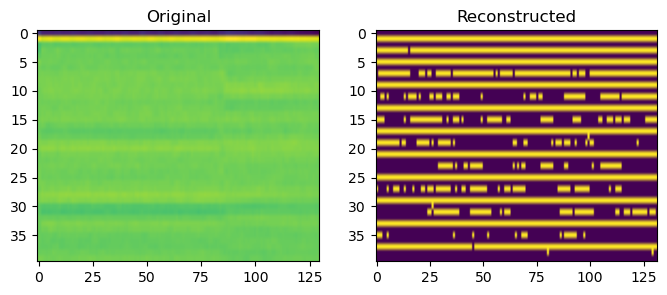

In [58]:
x = next(iter(loader))[0][:1].to(device)
recon, _, _, _ = model(x)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(x[0][0].cpu(), aspect='auto')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(recon[0][0].detach().cpu(), aspect='auto')
plt.title("Reconstructed")

plt.show()

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=16)
X_pca = pca.fit_transform(raw)

labels_pca = KMeans(n_clusters=best_k).fit_predict(X_pca)

print("PCA:", silhouette_score(X_pca, labels_pca))

PCA: 0.4356718957424164


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [61]:
import torch.nn as nn

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Linear(5200, 16)
        self.dec = nn.Linear(16, 5200)

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

ae = AE().to(device)

X_flat = torch.tensor(raw, dtype=torch.float32).to(device)

for _ in range(3):
    out, z = ae(X_flat)
    loss = ((out - X_flat)**2).mean()
    loss.backward()

z = z.detach().cpu().numpy()

labels_ae = KMeans(n_clusters=best_k).fit_predict(z)

print("AE:", silhouette_score(z, labels_ae))

AE: 0.3670082986354828


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [62]:
import torch.nn as nn

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Linear(5200, 16)
        self.dec = nn.Linear(16, 5200)

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

ae = AE().to(device)

X_flat = torch.tensor(raw, dtype=torch.float32).to(device)

for _ in range(3):
    out, z = ae(X_flat)
    loss = ((out - X_flat)**2).mean()
    loss.backward()

z = z.detach().cpu().numpy()

labels_ae = KMeans(n_clusters=best_k).fit_predict(z)

print("AE:", silhouette_score(z, labels_ae))

AE: 0.36551177501678467


D:\Anaconda\envs\soroni\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


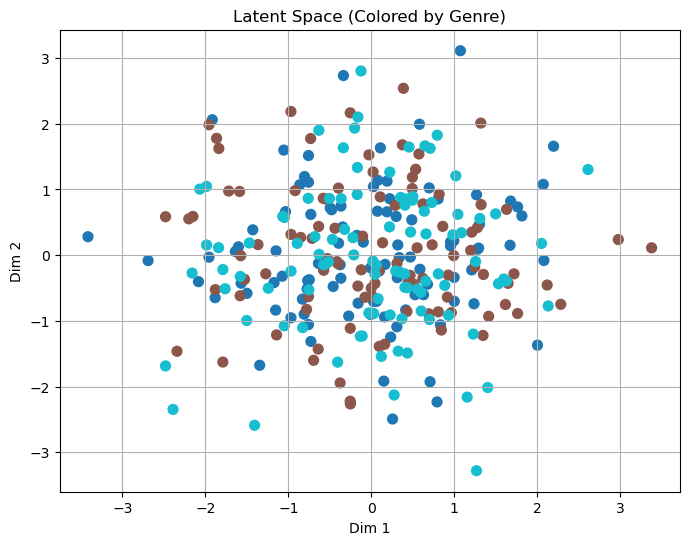

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

os.makedirs("../results/hard_task/plots", exist_ok=True)

pca2 = PCA(n_components=2)
Z = pca2.fit_transform(latent)

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=true_labels, cmap='tab10', s=50)

plt.title("Latent Space (Colored by Genre)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.grid(True)
plt.savefig("../results/latent_visualization/latent_genre.png", dpi=300)
plt.show()

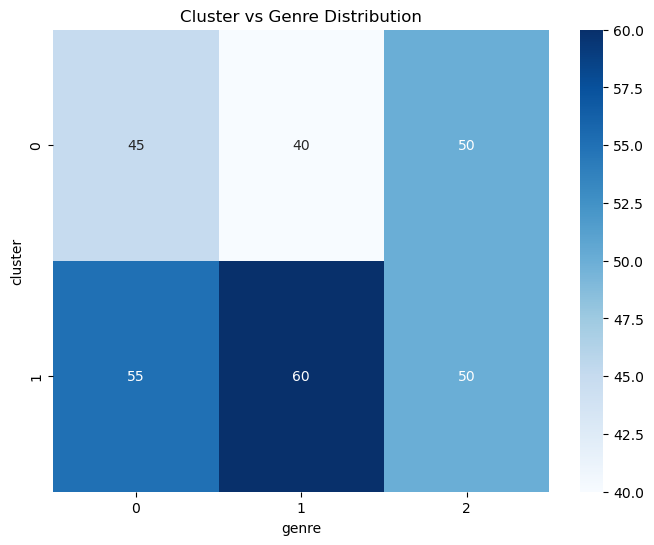

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "cluster": k_labels,
    "genre": true_labels
})

ct = pd.crosstab(df["cluster"], df["genre"])

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")

plt.title("Cluster vs Genre Distribution")
plt.savefig("../results/latent_visualization/cluster_distribution.png", dpi=300)
plt.show()

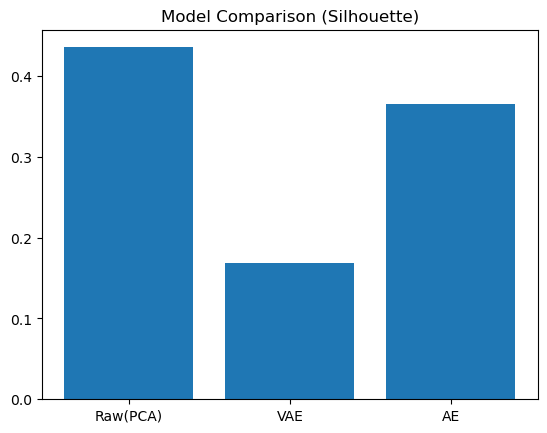

In [67]:
import matplotlib.pyplot as plt

methods = ["Raw(PCA)", "VAE", "AE"]
scores = [
    0.4356,
    silhouette_score(X, k_labels),
    silhouette_score(z, labels_ae)
]

plt.figure()
plt.bar(methods, scores)

plt.title("Model Comparison (Silhouette)")
plt.savefig("../results/latent_visualization/model_comparison.png", dpi=300)
plt.show()

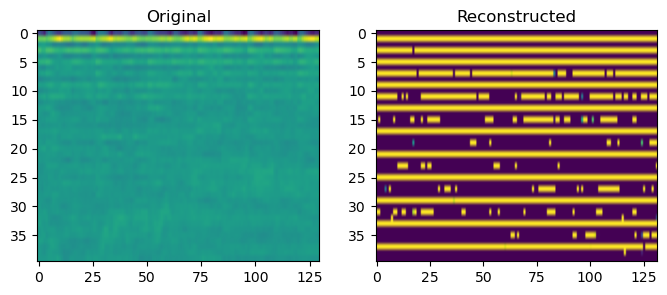

In [68]:
x = next(iter(loader))[0][:1].to(device)
recon, _, _, _ = model(x)

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(x[0][0].cpu(), aspect='auto')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(recon[0][0].detach().cpu(), aspect='auto')
plt.title("Reconstructed")

plt.savefig("../results/latent_visualization/reconstruction.png", dpi=300)
plt.show()

In [72]:
import pandas as pd
import os

os.makedirs("../results/hard_task", exist_ok=True)

df = pd.DataFrame({
    "Metric": ["Silhouette", "DB Index", "NMI", "ARI", "Purity"],
    "Value": [
        silhouette_score(X, k_labels),
        davies_bouldin_score(X, k_labels),
        normalized_mutual_info_score(true_labels, k_labels),
        adjusted_rand_score(true_labels, k_labels),
        purity_score(true_labels, k_labels)
    ]
})

df.to_csv("../results/hard_metrics.csv", index=False)
print("Saved hard_metrics.csv")

Saved hard_metrics.csv


In [71]:
df2 = pd.DataFrame({
    "Method": ["Raw(PCA)", "VAE", "Autoencoder"],
    "Silhouette": [
        0.4356,
        silhouette_score(X, k_labels),
        silhouette_score(z, labels_ae)
    ]
})

df2.to_csv("../results/model_comparison.csv", index=False)

In [73]:
df3 = pd.DataFrame({
    "file": names[:len(k_labels)],
    "cluster": k_labels,
    "true_label": true_labels
})

df3.to_csv("../results/cluster_assignments.csv", index=False)